# Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/featured_churn.csv')
print("Shape:", df.shape)

Shape: (7032, 23)


In [5]:
cluster_features = [
    'tenure',
    'MonthlyCharges',
    'ChargesPerTenure',
    'NumAddons',
    'IsLongTermContract',
    'Contract_Month-to-month',
    'Contract_Two year',
    'InternetService_Fiber optic',
    'InternetService_DSL',
    'TechSupport',
    'OnlineSecurity',
    'PaperlessBilling',
    'HasStreaming',
    'IsAutoPayment',
    'TenureGroup',
    'Dependents',
]

# Verify
missing = [f for f in cluster_features if f not in df.columns]
print("Missing features:", missing)  # Should be []

X_cluster = df[cluster_features].copy()
print("Clustering feature set shape:", X_cluster.shape)
print(X_cluster.head(3))

Missing features: []
Clustering feature set shape: (7032, 16)
     tenure  MonthlyCharges  ChargesPerTenure  NumAddons  IsLongTermContract  \
0 -1.280248       -1.161694          1.075091          1                   0   
1  0.064303       -0.260878         -0.477159          2                   1   
2 -1.239504       -0.363923          1.428197          2                   0   

   Contract_Month-to-month  Contract_Two year  InternetService_Fiber optic  \
0                        1                  0                            0   
1                        0                  0                            0   
2                        1                  0                            0   

   InternetService_DSL  TechSupport  OnlineSecurity  PaperlessBilling  \
0                    1            0               0                 1   
1                    1            0               1                 0   
2                    1            0               1                 1   

   HasStrea

In [6]:
cluster_scaler = StandardScaler()
X_scaled = cluster_scaler.fit_transform(X_cluster)

joblib.dump(cluster_scaler, '../models/cluster_scaler.pkl')
print("Cluster scaler saved.")
print("X_scaled shape:", X_scaled.shape)

Cluster scaler saved.
X_scaled shape: (7032, 16)


K=2 | Inertia=84913.2 | Silhouette=0.2339
K=3 | Inertia=71937.3 | Silhouette=0.2312
K=4 | Inertia=62522.2 | Silhouette=0.2295
K=5 | Inertia=56842.6 | Silhouette=0.2279
K=6 | Inertia=52294.5 | Silhouette=0.2224
K=7 | Inertia=49430.4 | Silhouette=0.2095
K=8 | Inertia=47284.3 | Silhouette=0.2096
K=9 | Inertia=45397.5 | Silhouette=0.1959
K=10 | Inertia=43854.3 | Silhouette=0.1875


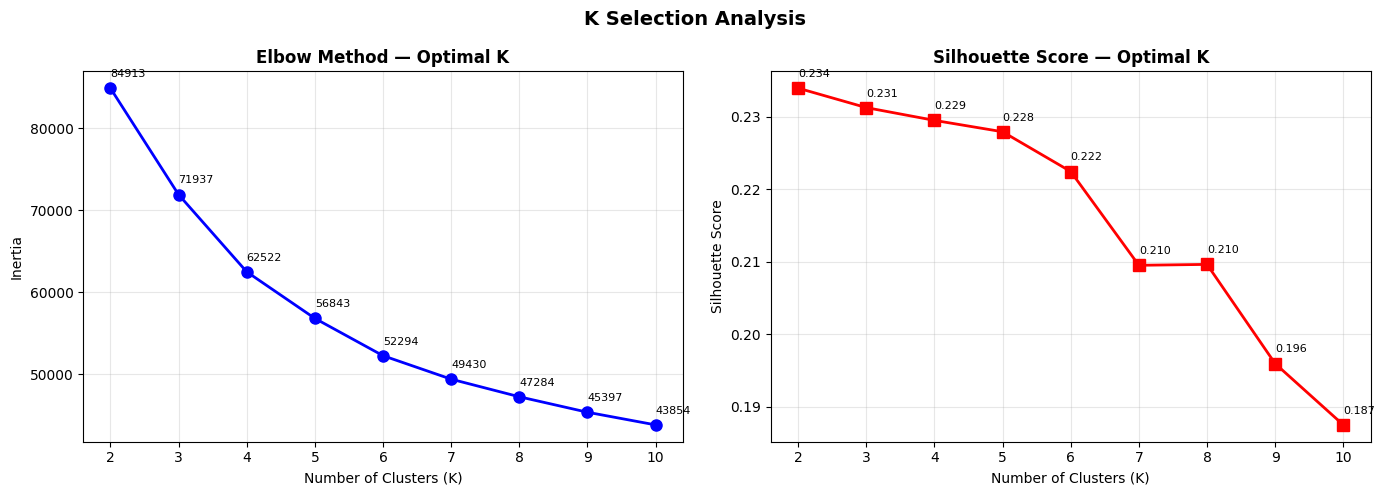


Best K by Silhouette : 2


In [7]:
inertia    = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"K={k} | Inertia={km.inertia_:.1f} | Silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].grid(True, alpha=0.3)
for k, val in zip(K_range, inertia):
    axes[0].annotate(f'{val:.0f}', (k, val),
                     textcoords='offset points', xytext=(0, 8), fontsize=8)

# Silhouette
axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Optimal K', fontweight='bold')
axes[1].grid(True, alpha=0.3)
for k, val in zip(K_range, sil_scores):
    axes[1].annotate(f'{val:.3f}', (k, val),
                     textcoords='offset points', xytext=(0, 8), fontsize=8)

plt.suptitle('K Selection Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/21_optimal_k.png', dpi=150)
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"\nBest K by Silhouette : {best_k}")

In [8]:
# K=4 gives meaningful business segments regardless of silhouette peak
# Segments: New-Risk, High-Value-Loyal, Senior-Vulnerable, Stable-Mid
FINAL_K = 4

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
kmeans.fit(X_scaled)

df['Segment'] = kmeans.labels_

joblib.dump(kmeans, '../models/kmeans_model.pkl')
joblib.dump(cluster_features, '../models/cluster_features.pkl')

print(f"KMeans fitted with K={FINAL_K}")
print(f"Segment distribution:\n{df['Segment'].value_counts().sort_index()}")

KMeans fitted with K=4
Segment distribution:
Segment
0    2126
1    2029
2    1744
3    1133
Name: count, dtype: int64


In [10]:
seg_analysis = df.groupby('Segment').agg(
    Count          = ('Churn', 'count'),
    Churn_Rate     = ('Churn', 'mean'),
    Avg_Tenure     = ('tenure', 'mean'),
    Avg_Monthly    = ('MonthlyCharges', 'mean'),
    Avg_Addons     = ('NumAddons', 'mean'),
    LongTerm_Pct   = ('IsLongTermContract', 'mean'),
    FiberOptic_Pct = ('InternetService_Fiber optic', 'mean'),
    Dependents_Pct = ('Dependents', 'mean'),
).round(3)

seg_analysis['Churn_Rate_Pct'] = (seg_analysis['Churn_Rate'] * 100).round(1)

print("=== SEGMENT ANALYSIS ===")
print(seg_analysis.to_string())

=== SEGMENT ANALYSIS ===
         Count  Churn_Rate  Avg_Tenure  Avg_Monthly  Avg_Addons  LongTerm_Pct  FiberOptic_Pct  Dependents_Pct  Churn_Rate_Pct
Segment                                                                                                                      
0         2126       0.547      -0.463        0.732       1.871         0.014           1.000           0.160            54.7
1         2029       0.092       0.961        0.654       4.097         0.961           0.465           0.386             9.2
2         1744       0.285      -0.801       -0.796       1.069         0.027           0.000           0.249            28.5
3         1133       0.020       0.381       -1.319       0.157         0.998           0.024           0.478             2.0


In [12]:
# Manually assign based on actual churn rates
# Segment 0 = 54.7% → Critical
# Segment 2 = 28.5% → Vulnerable  
# Segment 1 = 9.2%  → Stable
# Segment 3 = 2.0%  → Loyal

label_map = {
    0: 'Critical Churn-Risk',
    2: 'Vulnerable High-Risk',
    1: 'Stable Mid-Risk',
    3: 'Loyal Low-Risk'
}

df['Segment_Label'] = df['Segment'].map(label_map)

print("Segment Label Mapping:")
for seg, label in label_map.items():
    cr = seg_analysis.loc[seg, 'Churn_Rate_Pct']
    count = seg_analysis.loc[seg, 'Count']
    print(f"  Segment {seg} → {label:<25} | Churn Rate: {cr}% | Customers: {count}")

Segment Label Mapping:
  Segment 0 → Critical Churn-Risk       | Churn Rate: 54.7% | Customers: 2126
  Segment 2 → Vulnerable High-Risk      | Churn Rate: 28.5% | Customers: 1744
  Segment 1 → Stable Mid-Risk           | Churn Rate: 9.2% | Customers: 2029
  Segment 3 → Loyal Low-Risk            | Churn Rate: 2.0% | Customers: 1133


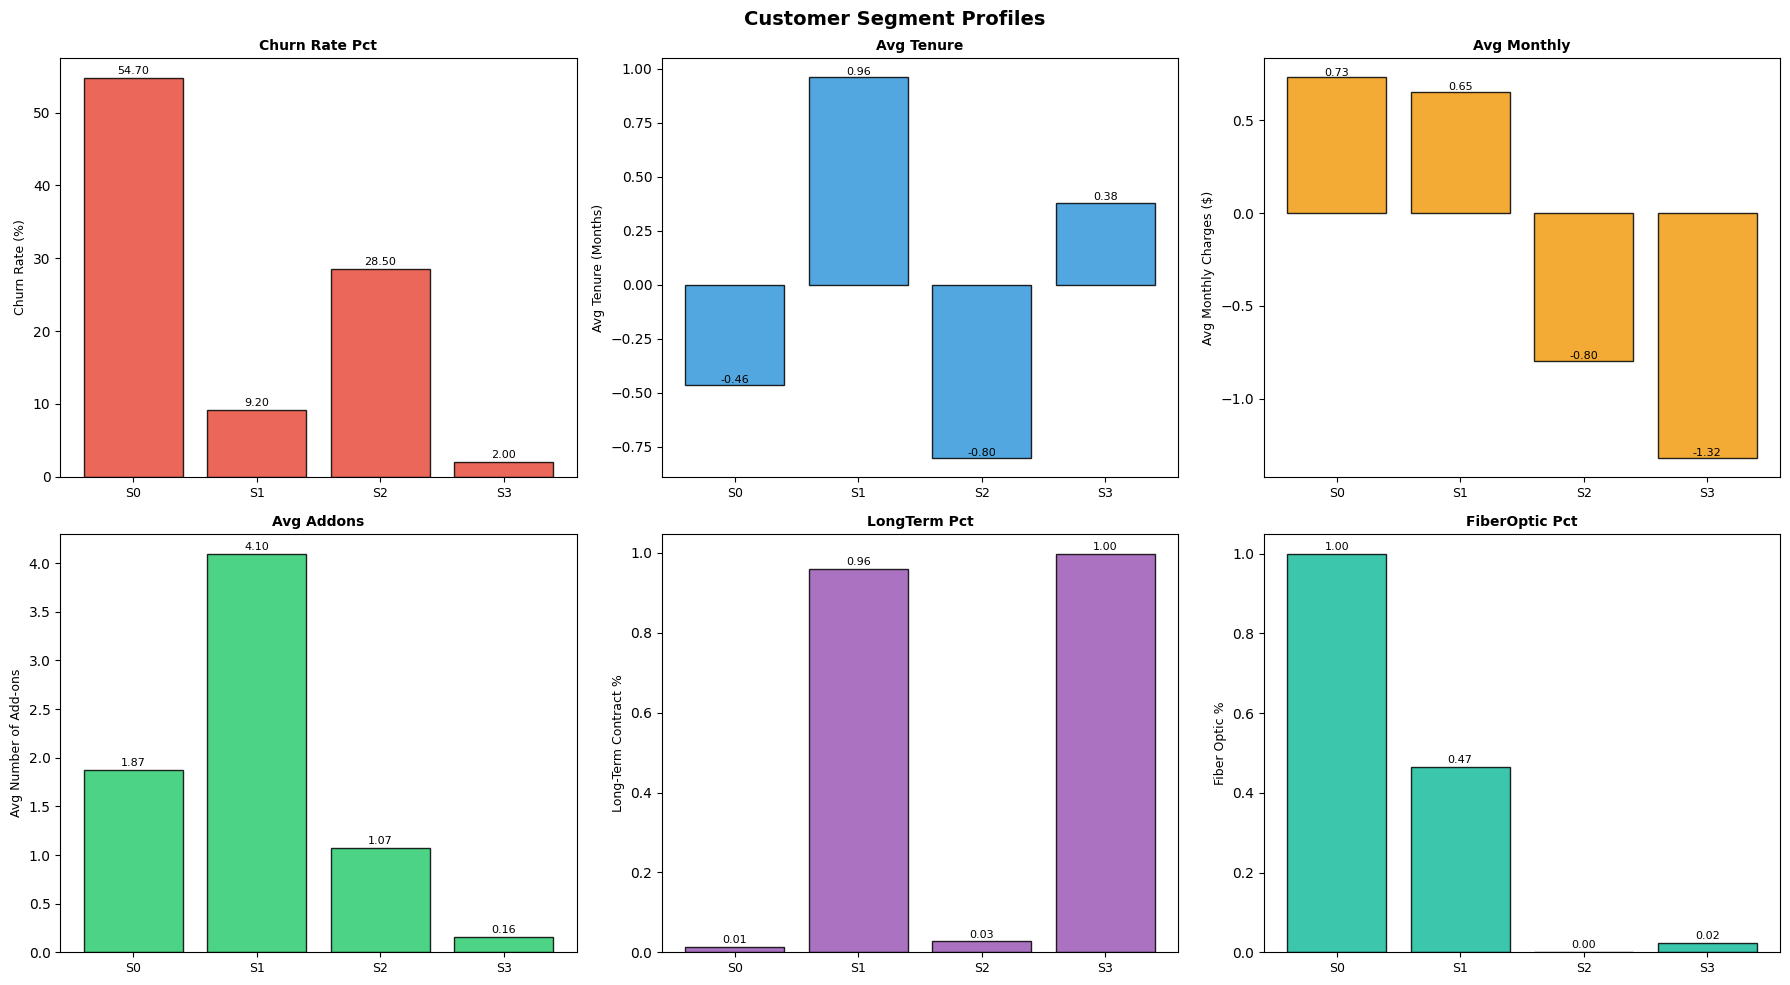

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = [
    ('Churn_Rate_Pct',  'Churn Rate (%)',        '#e74c3c'),
    ('Avg_Tenure',      'Avg Tenure (Months)',    '#3498db'),
    ('Avg_Monthly',     'Avg Monthly Charges ($)','#f39c12'),
    ('Avg_Addons',      'Avg Number of Add-ons',  '#2ecc71'),
    ('LongTerm_Pct',    'Long-Term Contract %',   '#9b59b6'),
    ('FiberOptic_Pct',  'Fiber Optic %',          '#1abc9c'),
]

seg_labels = [label_map[i] for i in range(FINAL_K)]

for ax, (metric, ylabel, color) in zip(axes, metrics):
    vals = [seg_analysis.loc[i, metric] for i in range(FINAL_K)]
    bars = ax.bar(range(FINAL_K), vals, color=color,
                  edgecolor='black', alpha=0.85)
    ax.set_xticks(range(FINAL_K))
    ax.set_xticklabels([f'S{i}' for i in range(FINAL_K)],
                       fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(metric.replace('_', ' '), fontweight='bold', fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * max(vals),
                f'{val:.2f}', ha='center', fontsize=8)

plt.suptitle('Customer Segment Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/22_segment_profiles.png', dpi=150)
plt.show()

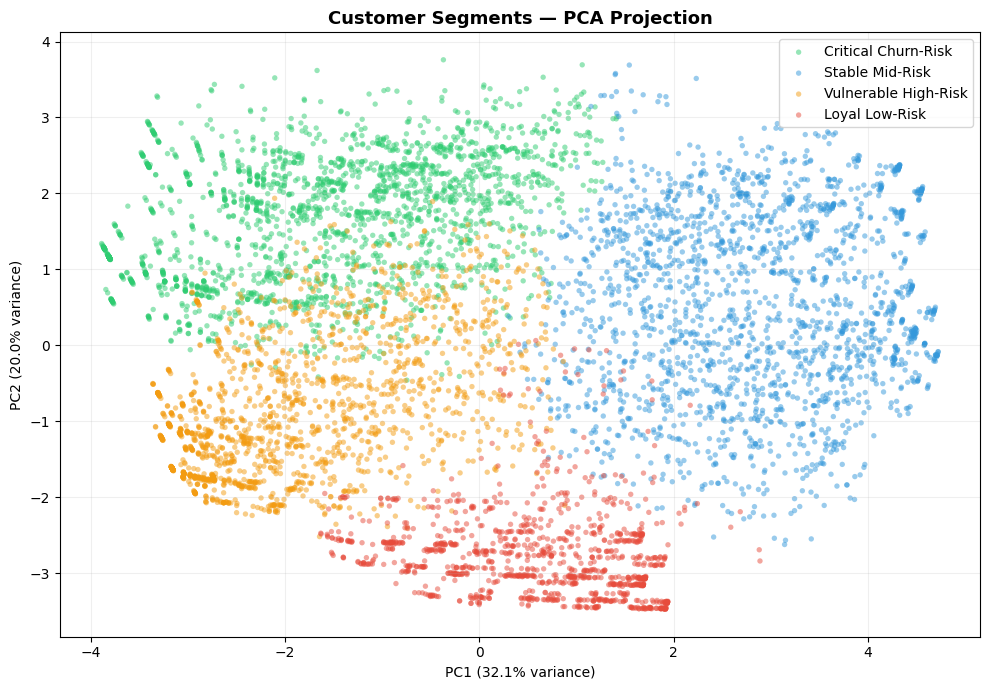

PCA Explained Variance: 52.1%


In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

colors  = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
labels  = [label_map[i] for i in range(FINAL_K)]

plt.figure(figsize=(10, 7))
for seg in range(FINAL_K):
    mask = df['Segment'] == seg
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[seg], label=labels[seg],
        alpha=0.5, s=15, edgecolors='none'
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Segments — PCA Projection', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/23_segment_pca.png', dpi=150)
plt.show()

print(f"PCA Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

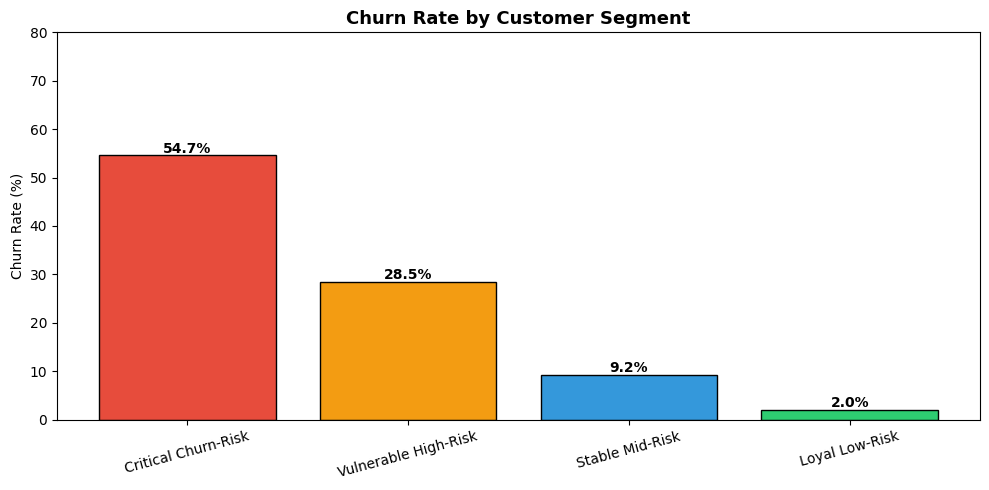

In [15]:
seg_churn = df.groupby('Segment_Label')['Churn'].mean().sort_values(ascending=False) * 100

colors_bar = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
plt.figure(figsize=(10, 5))
bars = plt.bar(seg_churn.index, seg_churn.values,
               color=colors_bar, edgecolor='black')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment', fontsize=13, fontweight='bold')
plt.xticks(rotation=15)
plt.ylim(0, 80)
for bar, val in zip(bars, seg_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/24_churn_by_segment.png', dpi=150)
plt.show()

In [17]:
# Load original cleaned data for readable stats
df_orig = pd.read_csv('../data/cleaned_churn.csv')

# Map segment labels using index alignment
df_orig['Segment_Label'] = df['Segment_Label'].values

summary = df_orig.groupby('Segment_Label').agg(
    Customers    = ('Churn', 'count'),
    Churn_Rate   = ('Churn', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Tenure   = ('tenure', lambda x: f"{x.mean():.0f} mo"),
    Avg_Monthly  = ('MonthlyCharges', lambda x: f"${x.mean():.0f}"),
).reset_index()

# Add addon info from featured data
addon_stats = df.groupby('Segment_Label').agg(
    Avg_Addons   = ('NumAddons', lambda x: f"{x.mean():.1f}"),
    LongTerm_Pct = ('IsLongTermContract', lambda x: f"{x.mean()*100:.0f}%"),
    FiberOptic   = ('InternetService_Fiber optic', lambda x: f"{x.mean()*100:.0f}%"),
).reset_index()

summary = summary.merge(addon_stats, on='Segment_Label')

# Sort by churn rate
summary['_sort'] = summary['Churn_Rate'].str.replace('%','').astype(float)
summary = summary.sort_values('_sort', ascending=False).drop(columns='_sort')
summary = summary.reset_index(drop=True)

print("=== FINAL SEGMENT SUMMARY ===")
print(summary.to_string(index=False))

=== FINAL SEGMENT SUMMARY ===
       Segment_Label  Customers Churn_Rate Avg_Tenure Avg_Monthly Avg_Addons LongTerm_Pct FiberOptic
 Critical Churn-Risk       2126      54.7%      21 mo         $87        1.9           1%       100%
Vulnerable High-Risk       1744      28.5%      13 mo         $41        1.1           3%         0%
     Stable Mid-Risk       2029       9.2%      56 mo         $84        4.1          96%        46%
      Loyal Low-Risk       1133       2.0%      42 mo         $25        0.2         100%         2%


In [18]:
df.to_csv('../data/segmented_churn.csv', index=False)

joblib.dump(label_map,   '../models/segment_label_map.pkl')
joblib.dump(FINAL_K,     '../models/final_k.pkl')

print("Saved:")
print("  data/segmented_churn.csv")
print("  models/kmeans_model.pkl")
print("  models/cluster_features.pkl")
print("  models/segment_label_map.pkl")

print("\n=== PHASE 9 COMPLETE ===")
print(f"Segments created : {FINAL_K}")
print("Segment labels   :", list(label_map.values()))

Saved:
  data/segmented_churn.csv
  models/kmeans_model.pkl
  models/cluster_features.pkl
  models/segment_label_map.pkl

=== PHASE 9 COMPLETE ===
Segments created : 4
Segment labels   : ['Critical Churn-Risk', 'Vulnerable High-Risk', 'Stable Mid-Risk', 'Loyal Low-Risk']
